In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el archivo CSV
df = pd.read_csv('/content/cleaned_5250.csv')
display(df.head())

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


# EDA

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5250 non-null   object 
 1   distance           5233 non-null   float64
 2   stellar_magnitude  5089 non-null   float64
 3   planet_type        5250 non-null   object 
 4   discovery_year     5250 non-null   int64  
 5   mass_multiplier    5227 non-null   float64
 6   mass_wrt           5227 non-null   object 
 7   radius_multiplier  5233 non-null   float64
 8   radius_wrt         5233 non-null   object 
 9   orbital_radius     4961 non-null   float64
 10  orbital_period     5250 non-null   float64
 11  eccentricity       5250 non-null   float64
 12  detection_method   5250 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 533.3+ KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance,5233.0,2167.168737,3245.522087,4.000000,389.000000,1371.000000,2779.000000,27727.00
stellar_magnitude,5089.0,12.683738,3.107571,0.872000,10.939000,13.543000,15.021000,44.61
discovery_year,5250.0,2015.732190,4.307336,1992.000000,2014.000000,2016.000000,2018.000000,2023.00
mass_multiplier,5227.0,6.434812,12.972727,0.020000,1.804000,4.170140,8.000000,752.00
radius_multiplier,5233.0,1.015121,0.603479,0.200000,0.325000,1.120000,1.410000,6.90
orbital_radius,4961.0,6.962942,138.673600,0.004400,0.053000,0.102800,0.286000,7506.00
orbital_period,5250.0,479.150875,16804.445318,0.000274,0.012594,0.034497,0.144216,1101369.90
eccentricity,5250.0,0.063568,0.141424,-0.520000,0.000000,0.000000,0.060000,0.95


In [4]:
def plot_class_distribution_vertical(df, var):
    var_count = df[var].value_counts()
    var_count.plot.bar()
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [5]:
def plot_class_distribution_horizontal(df, var):
    var_count = df[var].value_counts()
    var_count.plot.barh()
    plt.title(f"Distribución de {var}")
    plt.xlabel("Count")
    plt.ylabel(var)
    plt.xticks(rotation=0)
    plt.show()

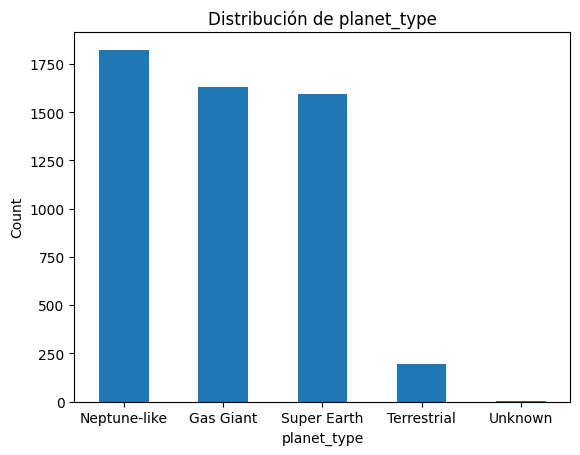

In [6]:
plot_class_distribution_vertical(df, 'planet_type')

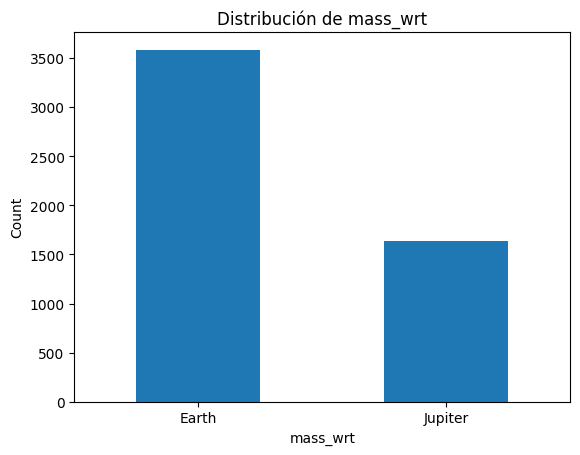

In [7]:
plot_class_distribution_vertical(df, 'mass_wrt')

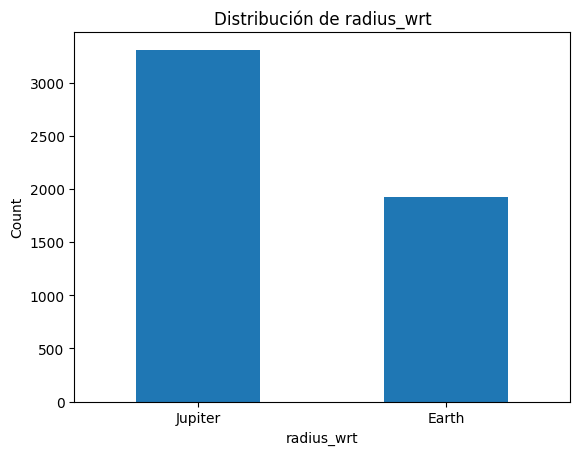

In [8]:
plot_class_distribution_vertical(df, 'radius_wrt')

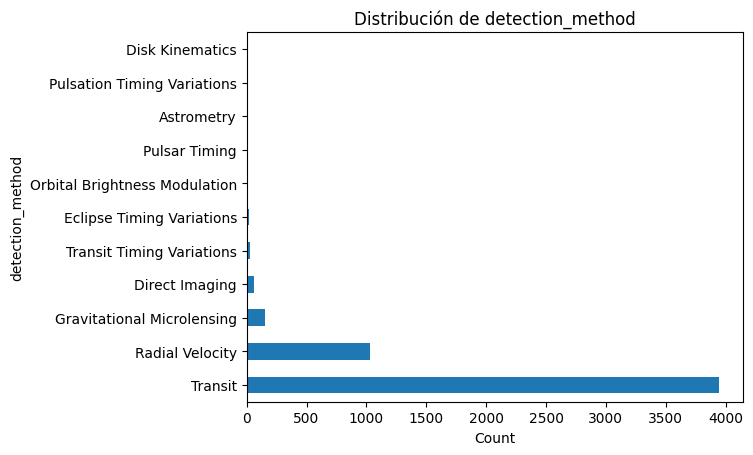

In [9]:
plot_class_distribution_horizontal(df, 'detection_method')

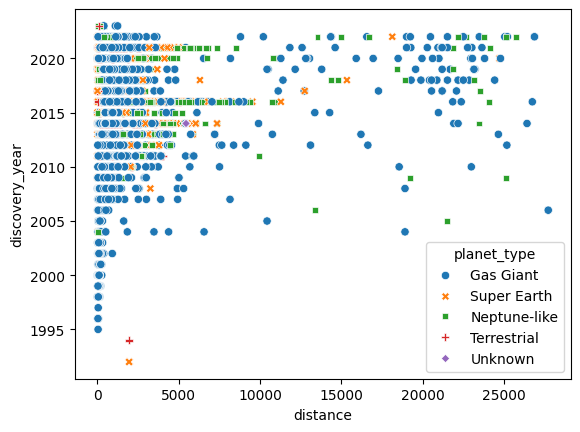

In [10]:
sns.scatterplot(x = 'distance', y = 'discovery_year', hue = 'planet_type', style = 'planet_type', data = df);

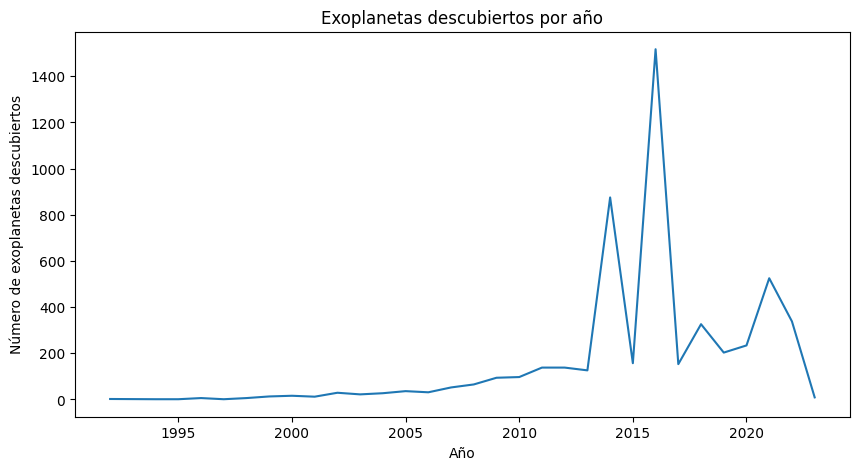

In [11]:
discovery_by_year = df['discovery_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=discovery_by_year.index, y=discovery_by_year.values)
plt.xlabel('Año')
plt.ylabel('Número de exoplanetas descubiertos')
plt.title('Exoplanetas descubiertos por año')
plt.show()

In [12]:
df.isnull().sum()

,0
name,0
distance,17
stellar_magnitude,161
planet_type,0
discovery_year,0
mass_multiplier,23
mass_wrt,23
radius_multiplier,17
radius_wrt,17
orbital_radius,289


# Preproceso

In [13]:
# Quiero la masa y el radio con la misma escala (multiplicador respecto a la Tierra)
# Fuente: https://nssdc.gsfc.nasa.gov/planetary/factsheet/jupiterfact.html
MASS_JUPITER_TO_EARTH = 317.8
RADIUS_JUPITER_TO_EARTH = 11.21

# Creo las nuevas columnas con esos multiplicadores
df['mass_earth'] = df.apply(
    lambda row: row['mass_multiplier'] if row['mass_wrt'] == 'Earth' else row['mass_multiplier'] * MASS_JUPITER_TO_EARTH,
    axis=1
)

df['radius_earth'] = df.apply(
    lambda row: row['radius_multiplier'] if row['radius_wrt'] == 'Earth' else row['radius_multiplier'] * RADIUS_JUPITER_TO_EARTH,
    axis=1
)

In [14]:
display(df.head())

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method,mass_earth,radius_earth
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity,6165.320000,12.1068
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity,4684.372000,12.2189
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity,1525.440000,12.8915
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity,2586.513818,12.5552
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity,565.684000,13.4520


In [15]:
df[['mass_earth', 'radius_earth']].describe().T

,count,mean,std,min,25%,50%,75%,max
mass_earth,5227.0,459.749044,3759.092646,0.020,3.97,8.47000,158.90000,238985.600
radius_earth,5233.0,5.631604,5.320645,0.296,1.76,2.73524,11.72566,77.349


# Guardar CSV

In [16]:
df.to_csv("/content/exoplanets_clean.csv", index=False, encoding='utf-8')